# 03.2 - Probability Distributions

**Difficulty:** Beginner
**Priority:** High — distributions are the language of ML

**Phase:** 03 - Statistics & Probability

**Status:** VERIFIED

---

## 1. What Are We Solving?

Data is generated by underlying **probability distributions**. Understanding which distribution describes your data tells you how to model it, what assumptions are valid, and which statistical tests to use. This unit covers the most important distributions: Bernoulli, Binomial, Normal, Uniform, and Poisson.

## 2. Why Does This Matter?

Choosing the right distribution is fundamental to modeling: classification uses Bernoulli/Binomial, regression assumes Normal errors, count data uses Poisson, and many ML algorithms assume data comes from a Normal distribution. Recognizing distributions lets you pick the right model and loss function.

## 3. Prerequisites

- Unit 02.5 (Probability)
- Unit 03.1 (Descriptive statistics)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Distinguish discrete and continuous distributions
- Understand Bernoulli and Binomial distributions
- Understand the Normal (Gaussian) distribution
- Understand Uniform and Poisson distributions
- Sample from distributions and visualize them
- Choose the right distribution for a problem

## 5. Mental Model

A **distribution** describes how likely each outcome is. **Discrete** distributions (Bernoulli, Binomial, Poisson) assign probability to specific integer values. **Continuous** distributions (Normal, Uniform) assign probability density over a range. Each distribution is defined by **parameters** (e.g. mean and std for Normal) that shape it.


## 6. Bernoulli Distribution

The **Bernoulli** distribution models a single binary outcome (success/failure, 0/1). It has one parameter `p` = probability of success.

- `P(X=1) = p`
- `P(X=0) = 1 - p`
- Mean = `p`, Variance = `p(1-p)`

This is the basis of binary classification (e.g. spam/not spam).


Bernoulli(p=0.7):
  Empirical P(X=1): 0.7113 (expected 0.7)
  Empirical mean:   0.7113 (theoretical 0.7)
  Empirical var:    0.2054 (theoretical 0.2100)


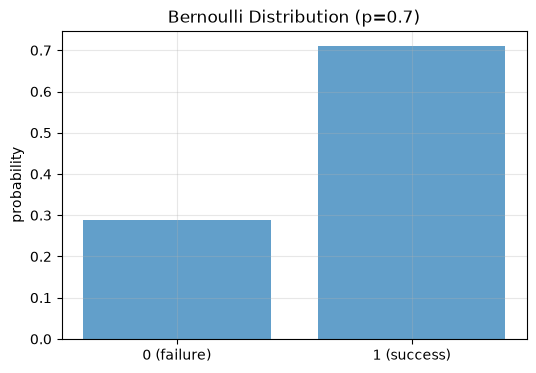

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Bernoulli: single coin flip
p = 0.7  # probability of success
np.random.seed(42)
samples = np.random.binomial(1, p, size=10000)

print(f"Bernoulli(p={p}):")
print(f"  Empirical P(X=1): {np.mean(samples):.4f} (expected {p})")
print(f"  Empirical mean:   {np.mean(samples):.4f} (theoretical {p})")
print(f"  Empirical var:    {np.var(samples):.4f} (theoretical {p*(1-p):.4f})")

plt.figure(figsize=(6, 4))
plt.bar([0, 1], [np.mean(samples == 0), np.mean(samples == 1)], alpha=0.7)
plt.xticks([0, 1], ["0 (failure)", "1 (success)"])
plt.ylabel("probability")
plt.title(f"Bernoulli Distribution (p={p})")
plt.grid(True, alpha=0.3)
plt.show()


## 7. Binomial Distribution

The **Binomial** distribution models the number of successes in `n` independent Bernoulli trials. Parameters: `n` (trials) and `p` (success probability).

- Mean = `n*p`, Variance = `n*p*(1-p)`

This models things like the number of heads in 10 coin flips, or the number of clicks out of 1000 impressions.


Binomial(n=20, p=0.5):
  Empirical mean: 9.99 (theoretical 10.0)
  Empirical var:  5.03 (theoretical 5.00)


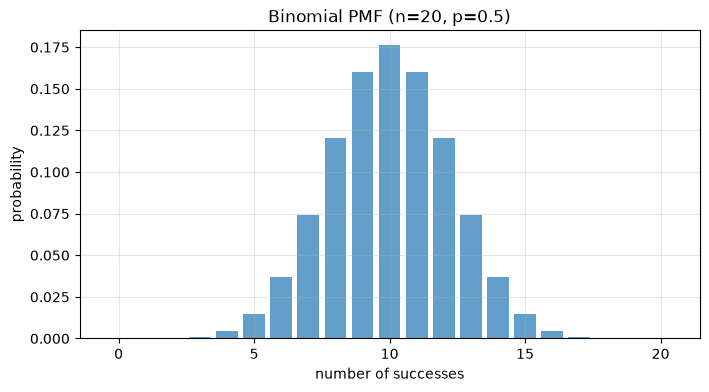

Most likely outcome: 10 successes


In [2]:
# Binomial: number of successes in n trials
n_trials = 20
p = 0.5
np.random.seed(1)
samples = np.random.binomial(n_trials, p, size=100000)

print(f"Binomial(n={n_trials}, p={p}):")
print(f"  Empirical mean: {np.mean(samples):.2f} (theoretical {n_trials*p})")
print(f"  Empirical var:  {np.var(samples):.2f} (theoretical {n_trials*p*(1-p):.2f})")

k = np.arange(0, n_trials + 1)
pmf = stats.binom.pmf(k, n_trials, p)

plt.figure(figsize=(8, 4))
plt.bar(k, pmf, alpha=0.7)
plt.xlabel("number of successes")
plt.ylabel("probability")
plt.title(f"Binomial PMF (n={n_trials}, p={p})")
plt.grid(True, alpha=0.3)
plt.show()
print(f"Most likely outcome: {np.argmax(pmf)} successes")


## 8. Normal (Gaussian) Distribution

The **Normal** distribution is the most important continuous distribution. Parameters: `mu` (mean) and `sigma` (std).

- Symmetric around the mean.
- ~68% within 1 std, ~95% within 2 std, ~99.7% within 3 std (empirical rule).
- The **Central Limit Theorem** makes it ubiquitous.

Many ML algorithms assume Normal-distributed data or errors.


Normal(mu=0, sigma=1):
  Empirical mean: -0.003 (theoretical 0)
  Empirical std:  1.002 (theoretical 1)

Empirical rule:
  Within 1 std: 0.684 (expected 0.683)
  Within 2 std: 0.953 (expected 0.954)
  Within 3 std: 0.997 (expected 0.997)


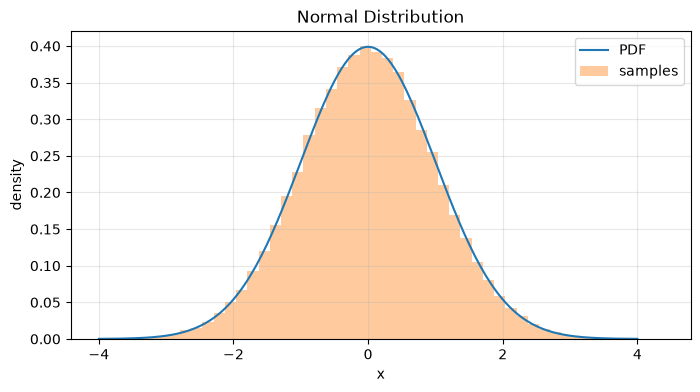

In [3]:
# Normal distribution
mu, sigma = 0, 1
np.random.seed(2)
samples = np.random.normal(mu, sigma, size=100000)

print(f"Normal(mu={mu}, sigma={sigma}):")
print(f"  Empirical mean: {np.mean(samples):.3f} (theoretical {mu})")
print(f"  Empirical std:  {np.std(samples):.3f} (theoretical {sigma})")

# Empirical rule
p1 = np.mean(np.abs(samples) < 1)
p2 = np.mean(np.abs(samples) < 2)
p3 = np.mean(np.abs(samples) < 3)
print(f"\nEmpirical rule:")
print(f"  Within 1 std: {p1:.3f} (expected 0.683)")
print(f"  Within 2 std: {p2:.3f} (expected 0.954)")
print(f"  Within 3 std: {p3:.3f} (expected 0.997)")

x = np.linspace(-4, 4, 200)
pdf = stats.norm.pdf(x, mu, sigma)
plt.figure(figsize=(8, 4))
plt.plot(x, pdf, label="PDF")
plt.hist(samples, bins=50, density=True, alpha=0.4, label="samples")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Normal Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 9. Uniform Distribution

The **Uniform** distribution assigns equal probability to all values in a range `[a, b]`. Parameters: `a` (low) and `b` (high).

- Mean = `(a+b)/2`, Variance = `(b-a)^2/12`

Used for random initialization, random sampling, and as the 'flat' prior in Bayesian analysis.


Uniform(0, 10):
  Empirical mean: 5.010 (theoretical 5.0)
  Empirical var:  8.351 (theoretical 8.333)
  Min: 0.000, Max: 10.000


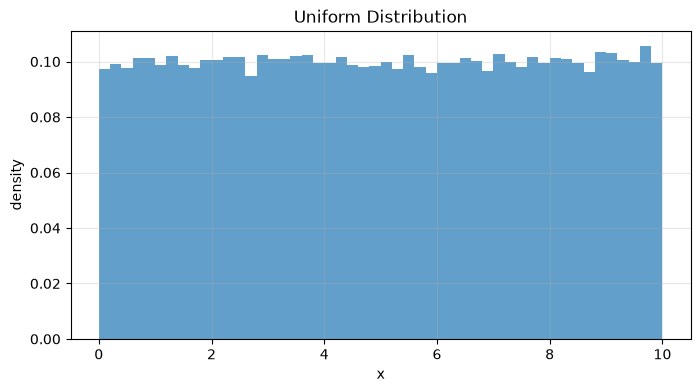

All values in [0, 10] are equally likely - the histogram is flat.


In [4]:
# Uniform distribution
a, b = 0, 10
np.random.seed(3)
samples = np.random.uniform(a, b, size=100000)

print(f"Uniform({a}, {b}):")
print(f"  Empirical mean: {np.mean(samples):.3f} (theoretical {(a+b)/2})")
print(f"  Empirical var:  {np.var(samples):.3f} (theoretical {(b-a)**2/12:.3f})")
print(f"  Min: {np.min(samples):.3f}, Max: {np.max(samples):.3f}")

plt.figure(figsize=(8, 4))
plt.hist(samples, bins=50, density=True, alpha=0.7)
plt.xlabel("x")
plt.ylabel("density")
plt.title("Uniform Distribution")
plt.grid(True, alpha=0.3)
plt.show()
print("All values in [0, 10] are equally likely - the histogram is flat.")


## 10. Poisson Distribution

The **Poisson** distribution models the number of events occurring in a fixed interval, given a rate `lambda`. It's used for count data: number of emails per hour, number of cars passing, number of defects.

- Mean = `lambda`, Variance = `lambda`

This is the go-to distribution for count data.


Poisson(lambda=3.0):
  Empirical mean: 2.995 (theoretical 3.0)
  Empirical var:  2.997 (theoretical 3.0)


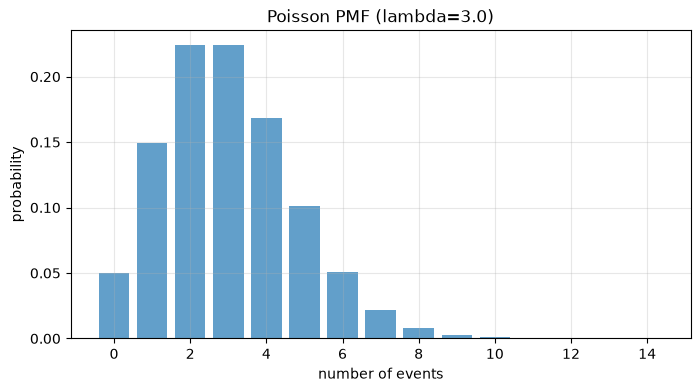

Poisson models count data - note mean == variance.


In [5]:
# Poisson distribution
lam = 3.0  # average rate
np.random.seed(4)
samples = np.random.poisson(lam, size=100000)

print(f"Poisson(lambda={lam}):")
print(f"  Empirical mean: {np.mean(samples):.3f} (theoretical {lam})")
print(f"  Empirical var:  {np.var(samples):.3f} (theoretical {lam})")

k = np.arange(0, 15)
pmf = stats.poisson.pmf(k, lam)

plt.figure(figsize=(8, 4))
plt.bar(k, pmf, alpha=0.7)
plt.xlabel("number of events")
plt.ylabel("probability")
plt.title(f"Poisson PMF (lambda={lam})")
plt.grid(True, alpha=0.3)
plt.show()
print("Poisson models count data - note mean == variance.")


## 11. Choosing the Right Distribution

How do you pick a distribution for your data?

| Data type | Distribution | Example |
|-----------|-------------|---------|
| Binary outcome | Bernoulli | spam/not spam |
| Count of successes | Binomial | heads in 10 flips |
| Continuous, symmetric | Normal | heights, test scores |
| Continuous, bounded | Uniform | random in [0,1] |
| Count of events | Poisson | emails per hour |
| Time between events | Exponential | time until next event |

Let's compare the shapes of several distributions side by side.


## When to Use Each Distribution

| Scenario | Distribution | Why |
|----------|-------------|-----|
| Click / no-click, spam / not-spam | Bernoulli | Single binary outcome |
| Count of successes in N trials | Binomial | Sum of Bernoulli trials |
| Heights, weights, measurement errors | Normal | CLT: many small additive effects |
| Random selection from a bounded range | Uniform | No prior knowledge of preference |
| Events per time interval (emails/hour, arrivals/min) | Poisson | Rare events in continuous time |
| Poisson with large lambda | Normal approximation | CLT again |

**Rule of thumb:** If you can count it → discrete (Bernoulli/Binomial/Poisson). If you measure it → continuous (Normal/Uniform).

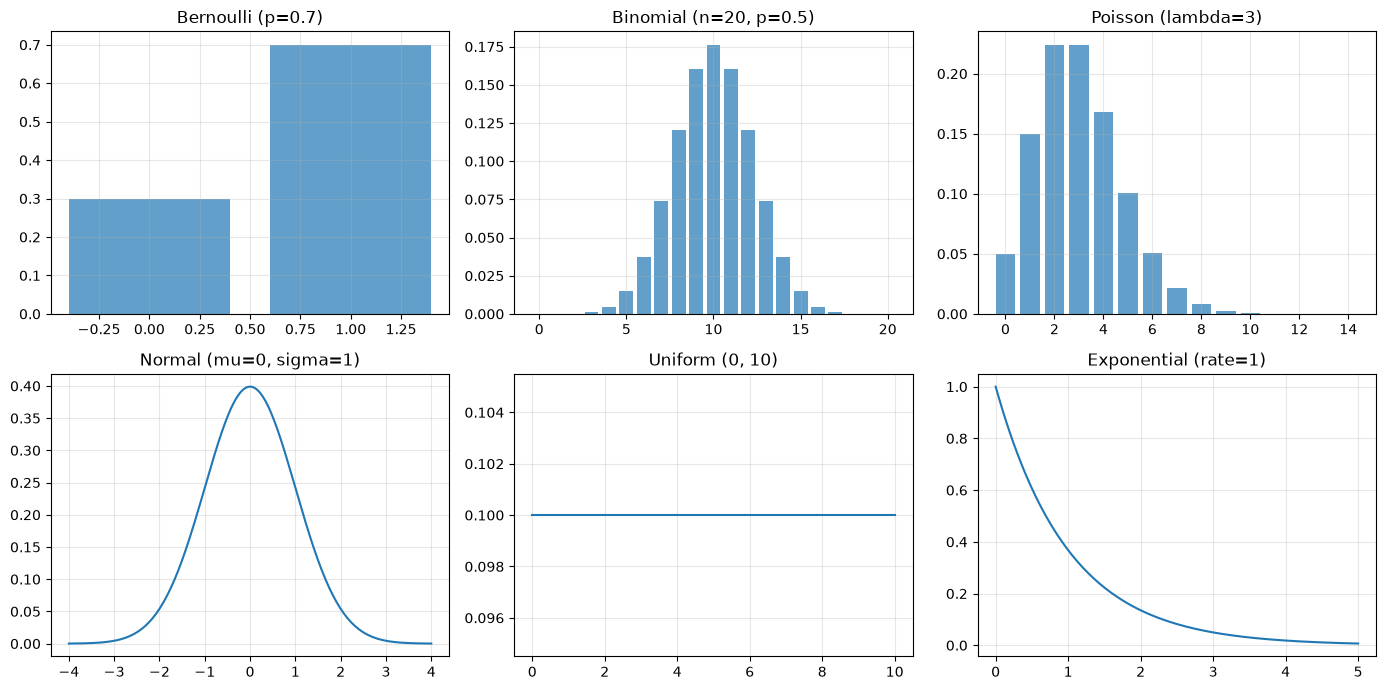

In [6]:
# Compare distribution shapes
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Bernoulli
axes[0, 0].bar([0, 1], [0.3, 0.7], alpha=0.7)
axes[0, 0].set_title("Bernoulli (p=0.7)")

# Binomial
k = np.arange(0, 21)
axes[0, 1].bar(k, stats.binom.pmf(k, 20, 0.5), alpha=0.7)
axes[0, 1].set_title("Binomial (n=20, p=0.5)")

# Poisson
k = np.arange(0, 15)
axes[0, 2].bar(k, stats.poisson.pmf(k, 3), alpha=0.7)
axes[0, 2].set_title("Poisson (lambda=3)")

# Normal
x = np.linspace(-4, 4, 200)
axes[1, 0].plot(x, stats.norm.pdf(x, 0, 1))
axes[1, 0].set_title("Normal (mu=0, sigma=1)")

# Uniform
x = np.linspace(0, 10, 200)
axes[1, 1].plot(x, stats.uniform.pdf(x, 0, 10))
axes[1, 1].set_title("Uniform (0, 10)")

# Exponential
x = np.linspace(0, 5, 200)
axes[1, 2].plot(x, stats.expon.pdf(x, scale=1))
axes[1, 2].set_title("Exponential (rate=1)")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Failure Case: Wrong Distribution Assumption

A common failure is assuming data is Normal when it's actually skewed or count-based. For example, modeling count data (Poisson) as if it were Normal can produce negative predictions, which are impossible for counts.


Count data (Poisson lambda=2):
  Min: 0, Max: 7
  Mean: 2.01, Var: 1.92
  Skew: 0.686 (positive - right-skewed)

If we model this as Normal, 67 of 1000 predictions are negative
(impossible for count data). Use Poisson instead.


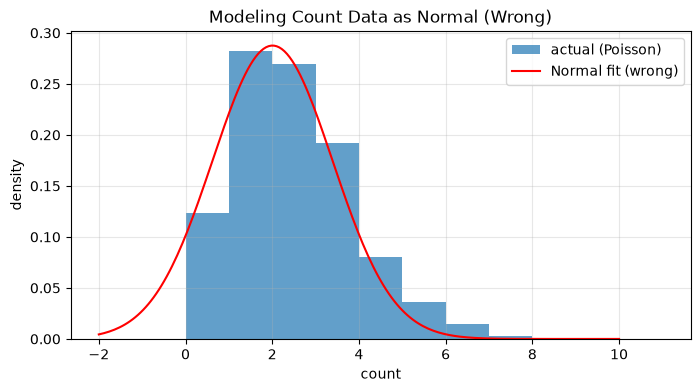

In [7]:
# Failure: modeling count data as Normal
np.random.seed(5)
counts = np.random.poisson(2, size=1000)  # actual count data

print(f"Count data (Poisson lambda=2):")
print(f"  Min: {np.min(counts)}, Max: {np.max(counts)}")
print(f"  Mean: {np.mean(counts):.2f}, Var: {np.var(counts):.2f}")
print(f"  Skew: {stats.skew(counts):.3f} (positive - right-skewed)")

# A Normal model would predict negative values (impossible for counts)
mu, sigma = np.mean(counts), np.std(counts)
normal_preds = np.random.normal(mu, sigma, 1000)
negatives = np.sum(normal_preds < 0)
print(f"\nIf we model this as Normal, {negatives} of 1000 predictions are negative")
print("(impossible for count data). Use Poisson instead.")

plt.figure(figsize=(8, 4))
plt.hist(counts, bins=range(0, 12), density=True, alpha=0.7, label="actual (Poisson)")
x = np.linspace(-2, 10, 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), "r-", label="Normal fit (wrong)")
plt.xlabel("count")
plt.ylabel("density")
plt.title("Modeling Count Data as Normal (Wrong)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 13. Debugging: Common Errors

- **Using Normal for count data**: use Poisson instead.
- **Using Normal for strictly positive skewed data**: use log-normal or exponential.
- **Confusing Binomial and Poisson**: Binomial has a fixed number of trials; Poisson models events over time/space.
- **Not checking the empirical rule**: if data isn't ~68% within 1 std, it's probably not Normal.

## 14. Real-World Considerations

- **Classification** uses Bernoulli/Binomial (via cross-entropy loss).
- **Regression** assumes Normal errors (via MSE loss).
- **Count data** (clicks, purchases) uses Poisson or negative binomial.
- **Survival/time-to-event** uses exponential or Weibull.
- **Random initialization** in neural networks uses uniform or normal.

## 15. Common Mistakes

- Assuming everything is Normal without checking.
- Using the wrong distribution for the data type.
- Ignoring skewness.
- Not verifying that empirical statistics match theoretical ones.

## 16. When NOT to Use

- Don't use Normal for count data or strictly positive skewed data.
- Don't use Uniform when outcomes are not equally likely.
- Don't use Binomial when trials are not independent.

## 17. Challenge

A website gets an average of 5 visits per minute. Model the number of visits in a minute with a Poisson distribution. What is the probability of getting exactly 5 visits? What is the probability of 10 or more?


## Common Mistakes

| Mistake | Why It's Wrong | Fix |
|---------|---------------|-----|
| Using Normal for click-through rates | Probabilities are bounded [0,1]; Normal allows negatives | Use Bernoulli / Beta-Binomial |
| Treating Poisson data as Normal for small lambda | Poisson is highly skewed when lambda < 10 | Use Poisson GLM or log-transform |
| Ignoring overdispersion in Binomial data | Real data often has variance > np(1-p) | Use Beta-Binomial or quasi-likelihood |
| Assuming Uniform priors are "uninformative" | Uniform can be informative on transformed scales | Use reference priors or check sensitivity |
| Forgetting to check if data is actually discrete | Counts modeled as continuous loses information | Verify data type before choosing distribution |

In [8]:
# Challenge: Poisson for website visits
lam = 5.0

# P(exactly 5 visits)
p_exact_5 = stats.poisson.pmf(5, lam)
# P(10 or more visits)
p_10_or_more = 1 - stats.poisson.cdf(9, lam)

print(f"Poisson(lambda={lam}) for website visits per minute:")
print(f"  P(exactly 5 visits) = {p_exact_5:.4f}")
print(f"  P(10 or more visits) = {p_10_or_more:.4f}")

# Verify by simulation
np.random.seed(6)
samples = np.random.poisson(lam, size=100000)
sim_exact = np.mean(samples == 5)
sim_10plus = np.mean(samples >= 10)
print(f"\nSimulation:")
print(f"  P(exactly 5) = {sim_exact:.4f}")
print(f"  P(10 or more) = {sim_10plus:.4f}")


Poisson(lambda=5.0) for website visits per minute:
  P(exactly 5 visits) = 0.1755
  P(10 or more visits) = 0.0318

Simulation:
  P(exactly 5) = 0.1742
  P(10 or more) = 0.0316


## Knowledge Check

1. You are building an email spam classifier. Which distribution models the label (spam/not-spam) for a single email? What about the total spam count out of 1000 emails?
2. Heights of adults in a city are approximately Normal(170, 10). What percentage of adults are between 150cm and 190cm? (Use the empirical rule.)
3. A website receives 5 visits per minute on average. What distribution models the visit count per minute? What is the probability of getting 0 visits in a given minute?
4. You have a dataset of daily temperatures. You compute the mean temperature over 365 days. According to the CLT, what distribution does this sample mean approximately follow?
5. Why is the Poisson distribution sometimes approximated by the Normal distribution?

## Exit Criteria Checklist

Before moving to the next notebook, verify you can:
- [ ] Identify whether a random variable is discrete or continuous
- [ ] Name the appropriate distribution for: binary outcomes, count data, measurement data, events-per-interval
- [ ] State the parameters of Bernoulli, Binomial, Normal, Uniform, and Poisson distributions
- [ ] Explain the empirical rule (68-95-99.7) and when it applies
- [ ] Explain why the CLT makes the Normal distribution ubiquitous
- [ ] Sample from any of these distributions using NumPy/SciPy
- [ ] Recognize when your distribution assumption is wrong (e.g., predicting negative values)

## Next Step

In Unit 03.3 (Inferential Statistics), we will use these distributions to make claims about populations from samples — confidence intervals, central limit theorem in action, and the foundations of statistical hypothesis testing.

## 18. Closed-Book Recall

Without looking back:

1. What is the difference between discrete and continuous distributions?
2. What does the Bernoulli distribution model?
3. What are the parameters of the Normal distribution?
4. When would you use Poisson instead of Normal?
5. What is the empirical rule for the Normal distribution?

## 19. Teach-Back Questions

Explain to another person:

- How do you choose between Binomial and Poisson?
- Why is the Normal distribution so common?
- Why is it wrong to model count data as Normal?

## 20. Summary

You now understand the key probability distributions: Bernoulli, Binomial, Normal, Uniform, and Poisson. You can sample from them, visualize them, verify their statistics, and choose the right one for your data.

## 21. Further Experiment

- Fit a distribution to real data and check goodness of fit.
- Explore the log-normal and exponential distributions.
- Use the Central Limit Theorem to see how sample means become Normal.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
